# Real dataset experiment: rolling Approximate Entropy on atmospheric CO₂

This notebook applies Approximate Entropy to a real time series bundled with
`statsmodels`, so the experiment stays fully reproducible offline.

We use the classic **Mauna Loa atmospheric CO₂** weekly series. The signal has trend,
seasonality, missing values, and local irregularities, which makes it a good example for
entropy-based feature engineering.

## Why this dataset is interesting

The CO₂ series is not white noise. It contains clear long-term structure. That is helpful,
because entropy becomes more meaningful when we compare:

- the **raw series**,
- the **detrended or residual series**,
- and a **rolling entropy feature** over time.

In applied work, this is often the right workflow: decompose first, then measure regularity.

In [1]:
from __future__ import annotations

from typing import Iterable, Sequence
import math

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


plt.rcParams["figure.figsize"] = (10, 4)


def to_1d_float_array(x: Sequence[float] | np.ndarray, *, name: str = "x") -> np.ndarray:
    """Validate and convert input to a 1D float NumPy array."""
    arr = np.asarray(x, dtype=float)
    if arr.ndim != 1:
        raise ValueError(f"{name} must be one-dimensional, got shape={arr.shape}.")
    if arr.size == 0:
        raise ValueError(f"{name} must contain at least one value.")
    if not np.isfinite(arr).all():
        raise ValueError(f"{name} contains NaN or infinite values.")
    return arr


def embed(series: Sequence[float] | np.ndarray, m: int) -> np.ndarray:
    """Return the delay-embedding matrix with lag 1 and dimension m."""
    x = to_1d_float_array(series)
    if not isinstance(m, int) or m < 1:
        raise ValueError("m must be a positive integer.")
    n = x.size
    if n <= m:
        raise ValueError(f"Need len(series) > m, got n={n}, m={m}.")
    return np.lib.stride_tricks.sliding_window_view(x, m)


def phi(series: Sequence[float] | np.ndarray, m: int, r: float) -> float:
    """Compute the ApEn phi_m quantity using the Chebyshev distance."""
    x = to_1d_float_array(series)
    if not np.isfinite(r) or r <= 0:
        raise ValueError("r must be a positive finite number.")

    patterns = embed(x, m)
    # Pairwise Chebyshev distance between all embedded vectors.
    distances = np.max(np.abs(patterns[:, None, :] - patterns[None, :, :]), axis=2)
    c_i = np.mean(distances <= r, axis=1)
    c_i = np.clip(c_i, 1e-12, None)
    return float(np.mean(np.log(c_i)))


def approximate_entropy(series: Sequence[float] | np.ndarray, m: int = 2, r: float | None = None) -> float:
    """Approximate Entropy (ApEn).

    Parameters
    ----------
    series:
        Input time series.
    m:
        Embedding dimension.
    r:
        Tolerance. If omitted, uses 0.2 * standard deviation of the series.
    """
    x = to_1d_float_array(series)
    if r is None:
        std = float(np.std(x, ddof=0))
        r = 0.2 * std if std > 0 else 0.2
    return phi(x, m, r) - phi(x, m + 1, r)


def sample_entropy(series: Sequence[float] | np.ndarray, m: int = 2, r: float | None = None) -> float:
    """Sample Entropy (SampEn) with Chebyshev distance."""
    x = to_1d_float_array(series)
    if r is None:
        std = float(np.std(x, ddof=0))
        r = 0.2 * std if std > 0 else 0.2
    if not np.isfinite(r) or r <= 0:
        raise ValueError("r must be a positive finite number.")

    def _count_matches(patterns: np.ndarray) -> float:
        distances = np.max(np.abs(patterns[:, None, :] - patterns[None, :, :]), axis=2)
        matches = (distances <= r).astype(float)
        np.fill_diagonal(matches, 0.0)
        return float(matches.sum())

    patterns_m = embed(x, m)
    patterns_m1 = embed(x, m + 1)

    b = _count_matches(patterns_m)
    a = _count_matches(patterns_m1)

    if a == 0.0 or b == 0.0:
        return float("inf")
    return float(-np.log(a / b))


def zscore(series: Sequence[float] | np.ndarray) -> np.ndarray:
    """Standardize a numeric series."""
    x = to_1d_float_array(series)
    std = float(np.std(x, ddof=0))
    if std == 0.0:
        return np.zeros_like(x)
    return (x - np.mean(x)) / std

C:\Users\diogo\AppData\Roaming\Python\Python312\site-packages\pandas\core\computation\expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
C:\Users\diogo\AppData\Roaming\Python\Python312\site-packages\pandas\core\arrays\masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.7' currently installed).
  from pandas.core import (


In [2]:
import statsmodels.api as sm
from statsmodels.tsa.seasonal import STL

co2 = sm.datasets.co2.load_pandas().data.copy()
co2 = co2.rename(columns={"co2": "value"})
co2.index = pd.to_datetime(co2.index)
co2["value"] = co2["value"].interpolate(limit_direction="both")
co2 = co2.dropna()

co2.head()

,value
1958-03-29,316.1
1958-04-05,317.3
1958-04-12,317.6
1958-04-19,317.5
1958-04-26,316.4


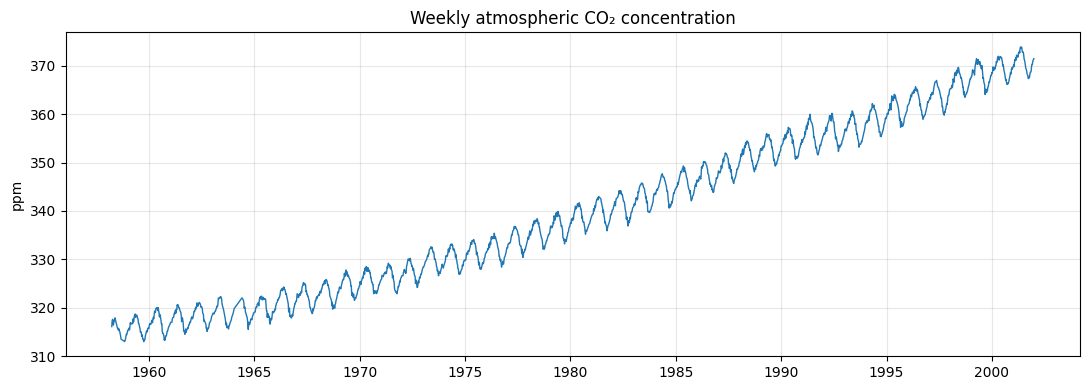

In [3]:
fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(co2.index, co2["value"], linewidth=1.0)
ax.set_title("Weekly atmospheric CO₂ concentration")
ax.set_ylabel("ppm")
ax.grid(alpha=0.3)
plt.tight_layout()

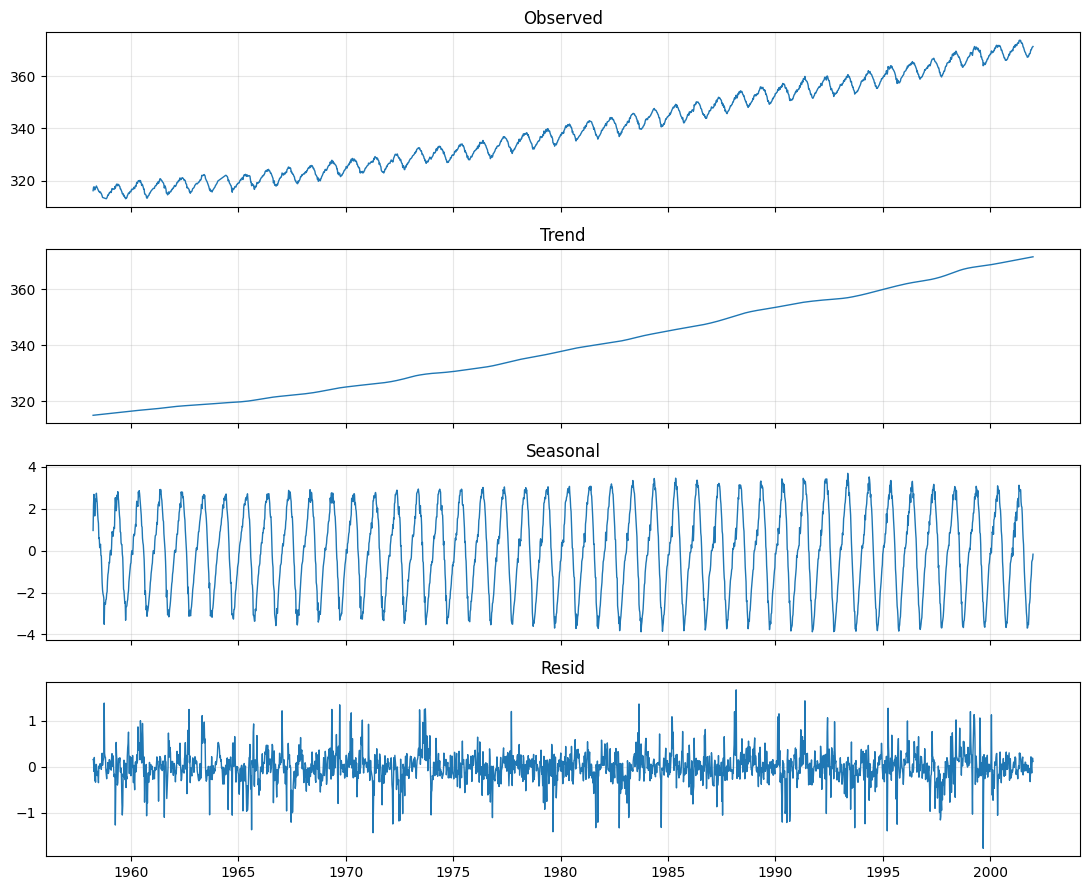

In [4]:
stl = STL(co2["value"], period=52, robust=True)
res = stl.fit()

decomp_df = pd.DataFrame(
    {
        "observed": co2["value"],
        "trend": res.trend,
        "seasonal": res.seasonal,
        "resid": res.resid,
    },
    index=co2.index,
)

fig, axes = plt.subplots(4, 1, figsize=(11, 9), sharex=True)
for ax, column in zip(axes, ["observed", "trend", "seasonal", "resid"]):
    ax.plot(decomp_df.index, decomp_df[column], linewidth=1.0)
    ax.set_title(column.title())
    ax.grid(alpha=0.3)
plt.tight_layout()

## Entropy on raw data versus residual structure

In [5]:
global_summary = pd.DataFrame(
    [
        {
            "series": "raw_co2",
            "mean": float(co2["value"].mean()),
            "variance": float(co2["value"].var()),
            "ApEn": float(approximate_entropy(co2["value"].to_numpy(), m=2)),
            "SampEn": float(sample_entropy(co2["value"].to_numpy(), m=2)),
        },
        {
            "series": "stl_residual",
            "mean": float(decomp_df["resid"].mean()),
            "variance": float(decomp_df["resid"].var()),
            "ApEn": float(approximate_entropy(decomp_df["resid"].to_numpy(), m=2)),
            "SampEn": float(sample_entropy(decomp_df["resid"].to_numpy(), m=2)),
        },
    ]
)
global_summary

,series,mean,variance,ApEn,SampEn
0,raw_co2,339.652496,292.531800,0.064515,0.064002
1,stl_residual,-0.006129,0.118382,1.675059,1.724209


The raw signal contains strong deterministic structure. The residual component is much closer
to what analysts usually want to monitor for anomalies or regime shifts.

In [6]:
def rolling_apen(series: pd.Series, *, window: int, m: int = 2, r_factor: float = 0.2) -> pd.Series:
    values: list[float] = [np.nan] * (window - 1)
    x = series.to_numpy(dtype=float)

    for end in range(window, x.size + 1):
        segment = x[end - window : end]
        std = float(np.std(segment, ddof=0))
        r = r_factor * std if std > 0 else r_factor
        values.append(approximate_entropy(segment, m=m, r=r))
    return pd.Series(values, index=series.index)


window = 104  # roughly two years of weekly data
rolling_feature_df = pd.DataFrame(index=decomp_df.index)
rolling_feature_df["residual"] = decomp_df["resid"]
rolling_feature_df["rolling_std"] = decomp_df["resid"].rolling(window).std()
rolling_feature_df["rolling_apen"] = rolling_apen(decomp_df["resid"], window=window, m=2, r_factor=0.2)
rolling_feature_df["rolling_abs_mean"] = decomp_df["resid"].abs().rolling(window).mean()

rolling_feature_df.tail()

,residual,rolling_std,rolling_apen,rolling_abs_mean
2001-12-01,-0.028303,0.244995,0.698225,0.167185
2001-12-08,-0.136056,0.245124,0.704913,0.167952
2001-12-15,0.162752,0.245758,0.691802,0.168830
2001-12-22,0.186934,0.246450,0.702499,0.169581
2001-12-29,0.114623,0.246761,0.680297,0.170443


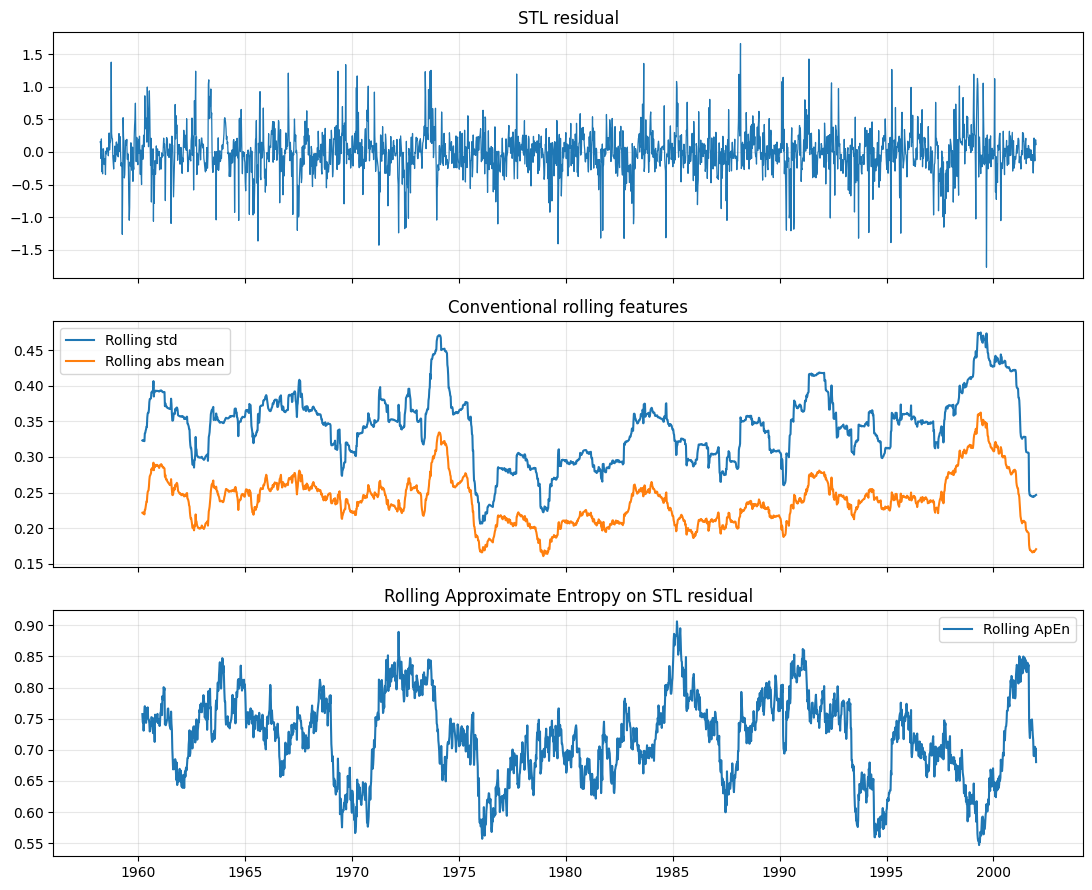

In [7]:
fig, axes = plt.subplots(3, 1, figsize=(11, 9), sharex=True)

axes[0].plot(decomp_df.index, decomp_df["resid"], linewidth=0.9)
axes[0].set_title("STL residual")
axes[0].grid(alpha=0.3)

axes[1].plot(rolling_feature_df.index, rolling_feature_df["rolling_std"], label="Rolling std")
axes[1].plot(rolling_feature_df.index, rolling_feature_df["rolling_abs_mean"], label="Rolling abs mean")
axes[1].set_title("Conventional rolling features")
axes[1].grid(alpha=0.3)
axes[1].legend()

axes[2].plot(rolling_feature_df.index, rolling_feature_df["rolling_apen"], label="Rolling ApEn")
axes[2].set_title("Rolling Approximate Entropy on STL residual")
axes[2].grid(alpha=0.3)
axes[2].legend()

plt.tight_layout()

In [8]:
top_irregular_periods = (
    rolling_feature_df[["rolling_apen"]]
    .dropna()
    .sort_values("rolling_apen", ascending=False)
    .head(12)
)

top_irregular_periods

,rolling_apen
1985-03-16,0.906300
1985-03-23,0.895765
1985-05-11,0.895257
1972-03-11,0.889451
1985-01-26,0.886206
1985-03-09,0.883515
1985-03-02,0.883515
1985-02-23,0.883210
1985-05-04,0.883067
1985-02-16,0.882291


## Interpretation

A high rolling standard deviation and a high rolling entropy are not the same thing.

- Standard deviation reacts to amplitude spread.
- Approximate Entropy reacts to pattern irregularity.

In practice, that means entropy can flag windows where the structure became harder to predict,
even when the variance did not increase dramatically.

## Ways to extend this experiment

1. Replace the CO₂ series with sunspots, river flow, or your own sensor data.
2. Compute ApEn on `observed`, `trend`, `seasonal`, and `resid` separately.
3. Add permutation entropy and compare the ranking of irregular periods.
4. Use the rolling entropy feature inside a forecasting or anomaly detection model.